In [1]:
from pathlib import Path
import csv
import datetime
import os
import sys
from dataclasses import dataclass
from typing import List, Tuple

notebook_dir = Path(os.getcwd())
project_root_dir = notebook_dir.parent
if str(project_root_dir) not in sys.path:
    sys.path.insert(0, str(project_root_dir))

import seaborn as sns
import matplotlib.pyplot as plt
import pyrallis
import pandas as pd
import numpy as np
import torch

from config import Config, TrainConfig, ModelConfig
from model import MLP
import logs

In [71]:
import importlib
importlib.reload(logs)

<module 'logs' from '/mnt/SharedOne/bpanthi/model_search/logs.py'>

In [2]:
study_dir = project_root_dir.joinpath("logs/hgf-20p")
trials = logs.read_study(study_dir)
df = logs.create_df(trials)
len(trials)

41

In [3]:
df.groupby(['optimizer','init'])['val_loss'].min()

optimizer  init
adagrad    ku      0.020704
           u       0.020574
           udd     0.306875
           xu      0.023084
adamw      ku      0.020574
rmsprop    ku      0.020582
Name: val_loss, dtype: float64

In [34]:
df.query('optimizer == "" & init =="ku" & lr == 0.001')['val_loss'].min()

np.float64(0.02058246729578962)

In [58]:
best_t = None 
for t in trials:
    if t.config.train.model.init == 'ku' and t.config.train.optim.optimizer == 'adagrad' and t.config.train.optim.weight_decay == 0.0:
        if not best_t or t.final_val_loss < best_t.final_val_loss:
            best_t = t 

best_t

Trial(name=20250530-162953-ZBjv
	config=Config(study_name='hgf-20p', dataset=DatasetConfig(db_file='dataset/HGF-20p.h5', label='HGF'), train=TrainConfig(device='cuda', loss='smoothl1', epoch=100, batch_size=1024, model=ModelConfig(init='ku', init_param=[], activation='relu', hidden_layers=[74], dropout=[]), optim=OptimizerConfig(optimizer='adagrad', lr=0.1, weight_decay=0.0)), tuning=None, logs_dir=PosixPath('logs')),
	train_loss=[..., [100, 0.0199861370348017, 561.486]],
	val_loss=[..., [100, 0.020715108885709745, 645.815]])

In [46]:
df.query('val_loss <= 0.2058')

,name,loss,batch_size,init,init_param,activation,hidden_layers,dropout,optimizer,lr,weight_decay,train_time,epoch,train_loss,val_loss
245,20250601-154440-iaSv,smoothl1,1024,ku,[],relu,[74],[],adagrad,0.001,0.00,88.716667,46,0.203336,0.203322
246,20250601-154440-iaSv,smoothl1,1024,ku,[],relu,[74],[],adagrad,0.001,0.00,88.716667,47,0.200247,0.200286
247,20250601-154440-iaSv,smoothl1,1024,ku,[],relu,[74],[],adagrad,0.001,0.00,88.716667,48,0.197240,0.197437
248,20250601-154440-iaSv,smoothl1,1024,ku,[],relu,[74],[],adagrad,0.001,0.00,88.716667,49,0.194321,0.194463
249,20250601-154440-iaSv,smoothl1,1024,ku,[],relu,[74],[],adagrad,0.001,0.00,88.716667,50,0.191481,0.191665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,20250530-202645-BqPC,smoothl1,1024,ku,[],relu,[74],[],adamw,0.010,0.01,76.000000,96,0.083281,0.133806
3896,20250530-202645-BqPC,smoothl1,1024,ku,[],relu,[74],[],adamw,0.010,0.01,76.000000,97,0.077159,0.085626
3897,20250530-202645-BqPC,smoothl1,1024,ku,[],relu,[74],[],adamw,0.010,0.01,76.000000,98,0.087666,0.088912
3898,20250530-202645-BqPC,smoothl1,1024,ku,[],relu,[74],[],adamw,0.010,0.01,76.000000,99,0.060668,0.086596


In [172]:
df = df[(df['optimizer'] == 'adagrad') & (df['lr'] == 0.01) & (df['weight_decay'] == 0)]
df['initialization'] = df['init'] + df['init_param'].astype(str)
df.to_csv("initialization_tune.csv")

In [173]:
dfu = df.query("init != 'udd' & train_loss < 100")
order = dfu.groupby('initialization')['train_loss'].min().sort_values().index.tolist()
order.reverse()
order

['u[-1.0, 1.0]',
 'u[-0.5, 0.5]',
 'xu[]',
 'ku[]',
 'u[-0.2, 0.2]',
 'u[-0.1, 0.1]',
 'u[-0.01, 0.01]']

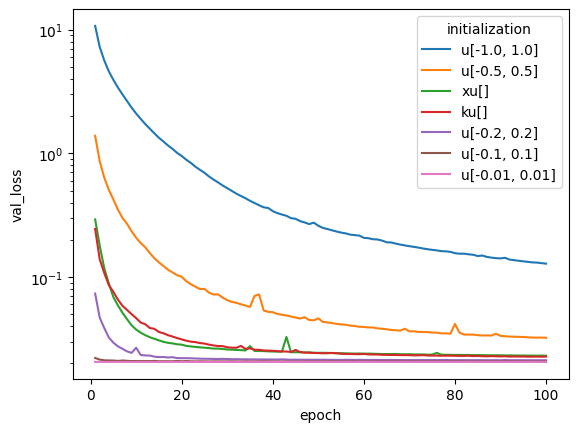

In [176]:
ax = sns.lineplot(dfu, x='epoch', y='val_loss', palette='tab10', hue='initialization', hue_order=order)
ax.set(yscale='log')
plt.savefig("val_loss_03.svg")

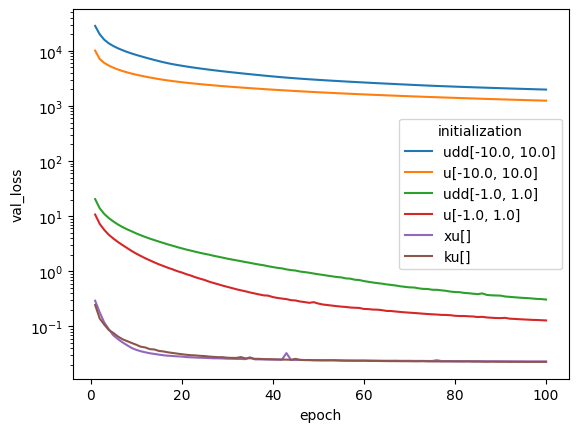

In [59]:
ax = sns.lineplot(df, x='epoch', y='val_loss', palette='tab10', hue='initialization', hue_order=order)
ax.set(yscale='log')
plt.savefig("val_loss_02.svg")

In [175]:
df.groupby(['initialization'])['val_loss'].min().sort_values()

initialization
u[-0.01, 0.01]         0.020574
u[-0.1, 0.1]           0.020686
u[-0.2, 0.2]           0.021214
ku[]                   0.022663
xu[]                   0.023084
u[-0.5, 0.5]           0.032251
u[-1.0, 1.0]           0.128225
udd[-1.0, 1.0]         0.306875
u[-10.0, 10.0]      1246.092895
udd[-10.0, 10.0]    1981.471181
Name: val_loss, dtype: float64

In [50]:
df['train_loss'].min(), df['val_loss'].min()

(np.float64(0.021218771654819384), np.float64(0.022662672710767367))

tensor(0.2882, dtype=torch.float64) tensor(-0.2884, dtype=torch.float64)


<Axes: ylabel='Count'>

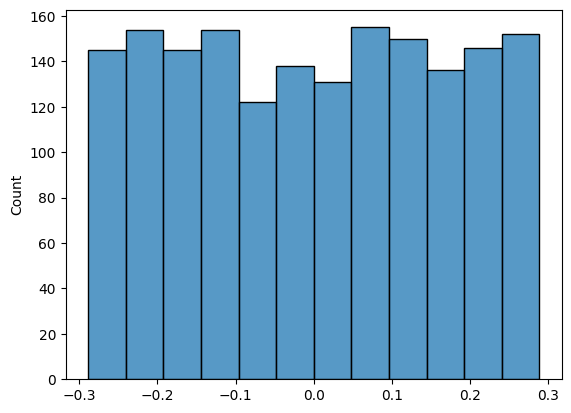

In [121]:
config =  ModelConfig(init="ku", init_param=[], activation="relu", hidden_layers=[72], dropout=[])
model = MLP(torch.device("cpu"), input_dim=74, output_dim=24, config=config)

def get_init_info(model):
    l1weight = model.model[2].weight.detach()
    w_max, w_min = l1weight.max(), l1weight.min()
    print(w_max, w_min)
    
get_init_info(model)
sns.histplot(model.model[2].weight.reshape(-1).detach())

<Axes: >

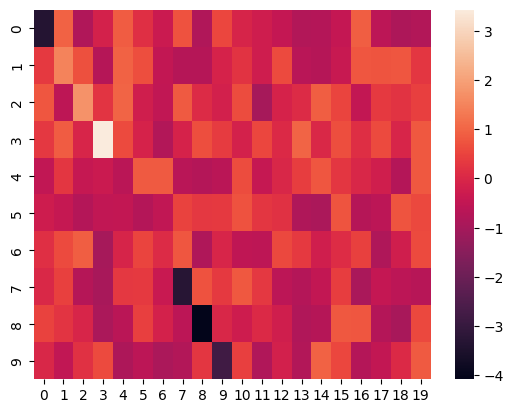

In [119]:
config =  ModelConfig(init="udd", init_param=[-1,1], activation="relu", hidden_layers=[10], dropout=[])
model = MLP(torch.device("cpu"), input_dim=20, output_dim=10, config=config)
sns.heatmap(model.model[0].weight.detach())